# Basic EDA: Loading data (read_csv), describe(), histograms and boxplots



## Workshop Plan

Three iterations, each with a different dataset:

| Iteration | Dataset | Rows | Type | Focus |
|-----------|---------|------|------|-------|
| 1 | Titanic | 891 | Mixed (categorical + numeric) | Survival patterns, outlier detection |
| 2 | Stock prices | 731 | Numeric time series | Price distributions, volatility |
| 3 | Weather | 731 | Numeric environmental | Correlations, seasonal patterns |

**Each iteration:**
- Load CSV, inspect shape/columns/summary stats
- Histograms with parameter exploration (bins, KDE, colors)
- Boxplots across features, identify outliers
- Correlation heatmap and scatter plots
- Observations and discussion

## Learning Objectives

By the end of this workshop, participants should be able to:

- Load and inspect datasets with `pd.read_csv()`, `.head()`, `.info()`, `.describe()`
- Detect missing values and understand data shapes
- Create histograms with parameter tuning (bins, KDE overlays, colors)
- Use boxplots to identify outliers and compare distributions
- Build correlation heatmaps and interpret relationships
- Apply these techniques to different data types and domains

## Setup: Download Datasets

This workshop requires three datasets. Run the cell below to automatically download them:

**Datasets:**
1. **Titanic** — Passenger survival data from seaborn public repository
2. **Stock Prices** — Simulated Apple stock daily data (2023-2024)
3. **Weather** — NYC weather data from Open-Meteo API (daily, 2023-2024)

All files will be saved to the `data/` folder in your working directory. If files already exist, they won't be re-downloaded.

In [1]:
import os
import pandas as pd

os.makedirs("data", exist_ok=True)

print("=" * 70)
print("DOWNLOADING DATASETS FOR WORKSHOP")
print("=" * 70)

# Titanic dataset
print("\n[1/3] Titanic dataset...")
try:
    if not os.path.exists("data/titanic.csv"):
        titanic = pd.read_csv('https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv')
        titanic.to_csv('data/titanic.csv', index=False)
        print(f" Downloaded: {titanic.shape[0]} rows, {titanic.shape[1]} columns")
    else:
        print(" Already exists")
except Exception as e:
    print(f"   Error: {e}")

# Stock data (Apple synthetic)
print("\n[2/3] Stock price data (Apple AAPL)...")
try:
    if not os.path.exists("data/stocks_aapl.csv"):
        import numpy as np
        np.random.seed(42)
        dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
        n = len(dates)
        prices = 150 + np.cumsum(np.random.randn(n) * 2)
        stock_df = pd.DataFrame({
            'Date': dates,
            'Close': prices,
            'Volume': np.random.randint(50000000, 150000000, n),
            'High': prices + np.abs(np.random.randn(n) * 2),
            'Low': prices - np.abs(np.random.randn(n) * 2),
        })
        stock_df.to_csv('data/stocks_aapl.csv', index=False)
        print(f" Generated: {stock_df.shape[0]} rows, {stock_df.shape[1]} columns")
    else:
        print(" Already exists")
except Exception as e:
    print(f"   Error: {e}")

# Weather data (Open-Meteo API)
print("\n[3/3] Weather data (NYC)...")
try:
    if not os.path.exists("data/weather_nyc.csv"):
        import urllib.request
        import json
        
        url = "https://archive-api.open-meteo.com/v1/archive?latitude=40.71&longitude=-74.01&start_date=2023-01-01&end_date=2024-12-31&hourly=temperature_2m,relative_humidity_2m,precipitation,wind_speed_10m"
        with urllib.request.urlopen(url, timeout=10) as response:
            data = json.loads(response.read())
        
        weather_df = pd.DataFrame({
            'time': data['hourly']['time'],
            'temperature': data['hourly']['temperature_2m'],
            'humidity': data['hourly']['relative_humidity_2m'],
            'precipitation': data['hourly']['precipitation'],
            'wind_speed': data['hourly']['wind_speed_10m']
        })
        
        weather_df = weather_df.iloc[::24].reset_index(drop=True)
        weather_df.to_csv('data/weather_nyc.csv', index=False)
        print(f"  Downloaded: {weather_df.shape[0]} rows, {weather_df.shape[1]} columns")
    else:
        print("  Already exists")
except Exception as e:
    print(f"   Error (fallback to synthetic): {e}")
    # Fallback: create synthetic weather data
    try:
        np.random.seed(42)
        dates = pd.date_range(start='2023-01-01', end='2024-12-31', freq='D')
        n = len(dates)
        weather_df = pd.DataFrame({
            'time': dates.astype(str),
            'temperature': 15 + 10 * np.sin(np.arange(n) * 2 * np.pi / 365) + np.random.randn(n) * 2,
            'humidity': 60 + np.random.randn(n) * 10,
            'precipitation': np.random.exponential(2, n),
            'wind_speed': 5 + np.random.exponential(1, n),
        })
        weather_df.to_csv('data/weather_nyc.csv', index=False)
        print(f" Generated (synthetic): {weather_df.shape[0]} rows, {weather_df.shape[1]} columns")
    except Exception as e2:
        print(f"   Fallback failed: {e2}")


DOWNLOADING DATASETS FOR WORKSHOP

[1/3] Titanic dataset...
 Already exists

[2/3] Stock price data (Apple AAPL)...
 Already exists

[3/3] Weather data (NYC)...
  Already exists


In [2]:
# Install dependencies as needed:
# pip install pandas seaborn matplotlib numpy
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

print("Libraries ready!")

Libraries ready!


---

# ITERATION 1: TITANIC DATASET

Explore survival patterns, passenger demographics, and fare distributions.

## 1.1 Load and inspect Titanic data

In [3]:
# Load the dataset
df = pd.read_csv("data/titanic.csv")

print("=" * 60)
print("TITANIC DATASET")
print("=" * 60)
print(f"Shape: {df.shape} (rows, columns)")
print(f"Columns: {list(df.columns)}")

print("\nFirst 5 rows:")
print(df.head())

print("\nData types and null values:")
print(df.info())

print("\nNumeric summary:")
print(df.describe())

TITANIC DATASET
Shape: (891, 15) (rows, columns)
Columns: ['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'deck', 'embark_town', 'alive', 'alone']

First 5 rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  


## 1.2 Histograms: Explore distributions

Numeric columns: ['survived', 'pclass', 'age', 'sibsp', 'parch', 'fare']


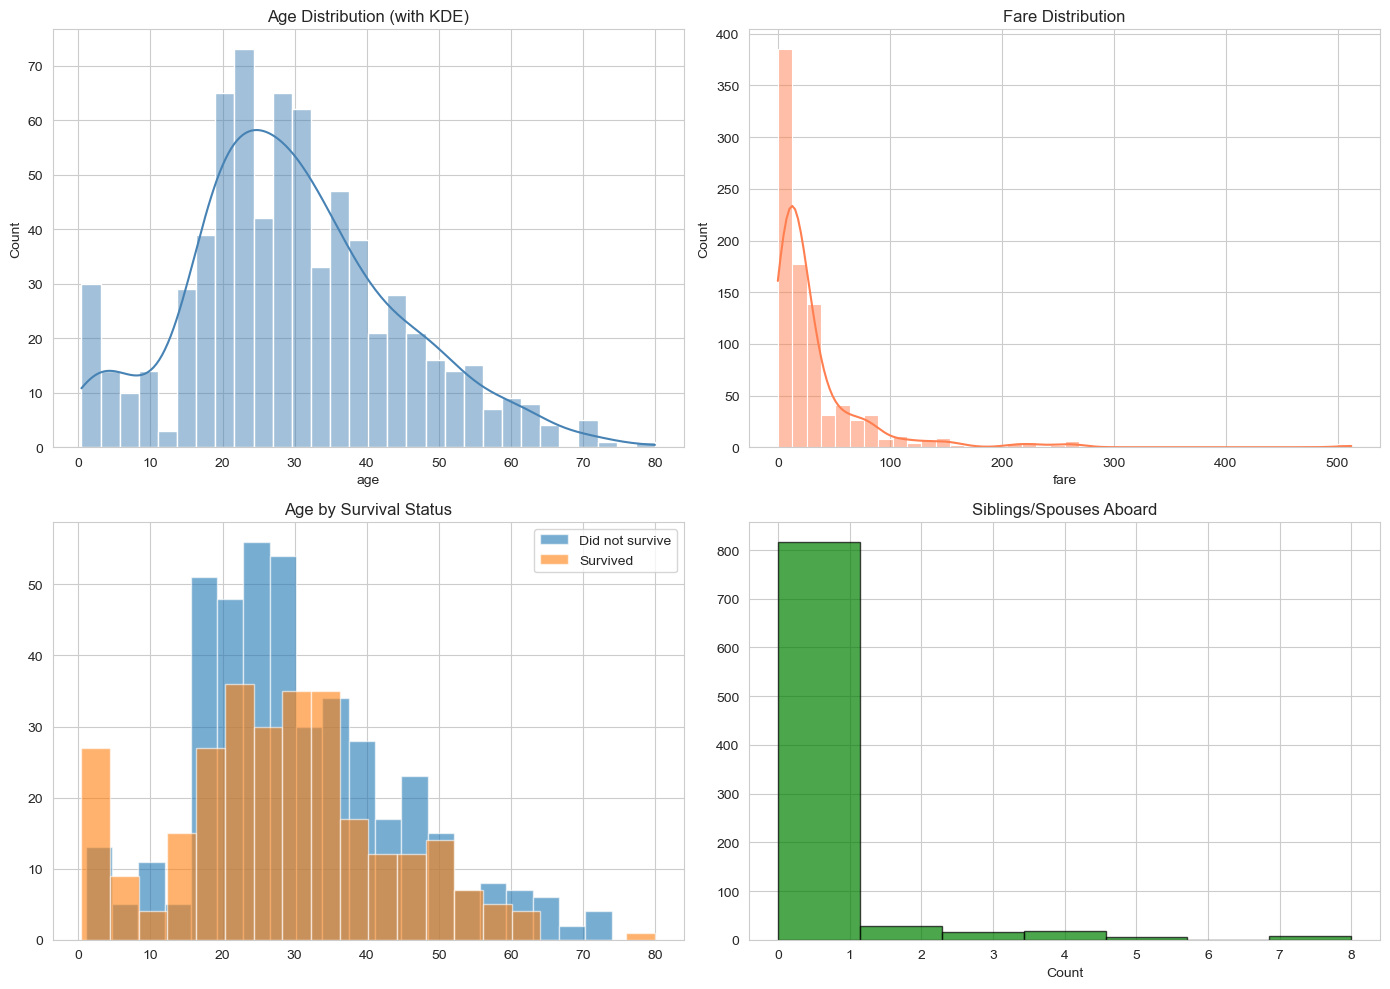

  Histograms complete


In [4]:
# Numeric columns for Titanic
numeric_cols_titanic = df.select_dtypes(include="number").columns.tolist()
print(f"Numeric columns: {numeric_cols_titanic}")

# Create histogram grid
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Age (with KDE)
sns.histplot(df["age"].dropna(), bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Age Distribution (with KDE)")

# Plot 2: Fare (log scale)
sns.histplot(df["fare"].dropna(), bins=40, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Fare Distribution")

# Plot 3: Age by survival
df.groupby("survived")["age"].hist(bins=20, ax=axes[2], alpha=0.6)
axes[2].set_title("Age by Survival Status")
axes[2].legend(["Did not survive", "Survived"])

# Plot 4: Custom histogram exploration
axes[3].hist(df["sibsp"], bins=7, edgecolor="black", color="green", alpha=0.7)
axes[3].set_title("Siblings/Spouses Aboard")
axes[3].set_xlabel("Count")

plt.tight_layout()
plt.show()

print("  Histograms complete")

## 1.3 Boxplots: Spot outliers and compare groups

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_94651/2549593134.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="pclass", y="age", data=df, ax=axes[0], palette="Set2")
/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_94651/2549593134.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="pclass", y="fare", data=df, ax=axes[1], palette="Set2")


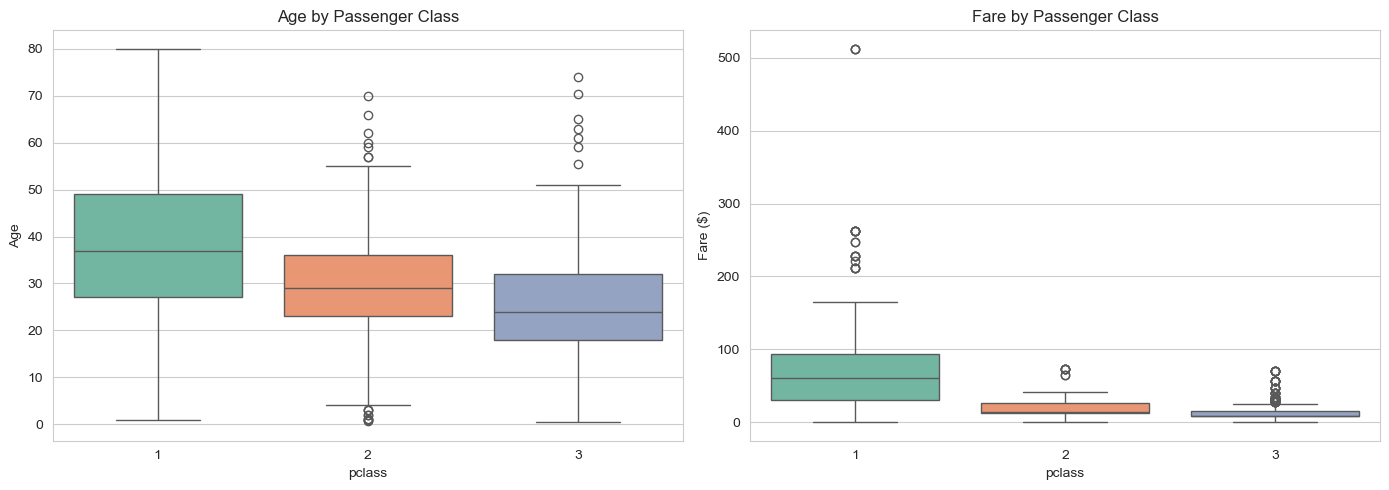

  Boxplots complete — note outliers in Fare distribution


In [5]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Boxplot 1: Age by passenger class
sns.boxplot(x="pclass", y="age", data=df, ax=axes[0], palette="Set2")
axes[0].set_title("Age by Passenger Class")
axes[0].set_ylabel("Age")

# Boxplot 2: Fare by passenger class
sns.boxplot(x="pclass", y="fare", data=df, ax=axes[1], palette="Set2")
axes[1].set_title("Fare by Passenger Class")
axes[1].set_ylabel("Fare ($)")

plt.tight_layout()
plt.show()

print("  Boxplots complete — note outliers in Fare distribution")

## 1.4 Correlations and relationships

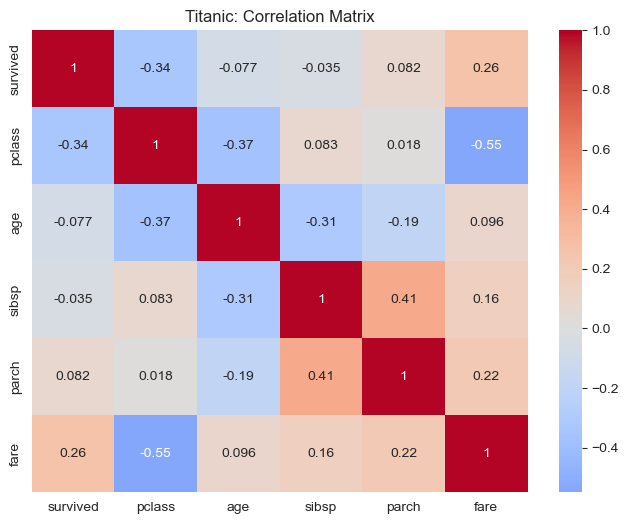

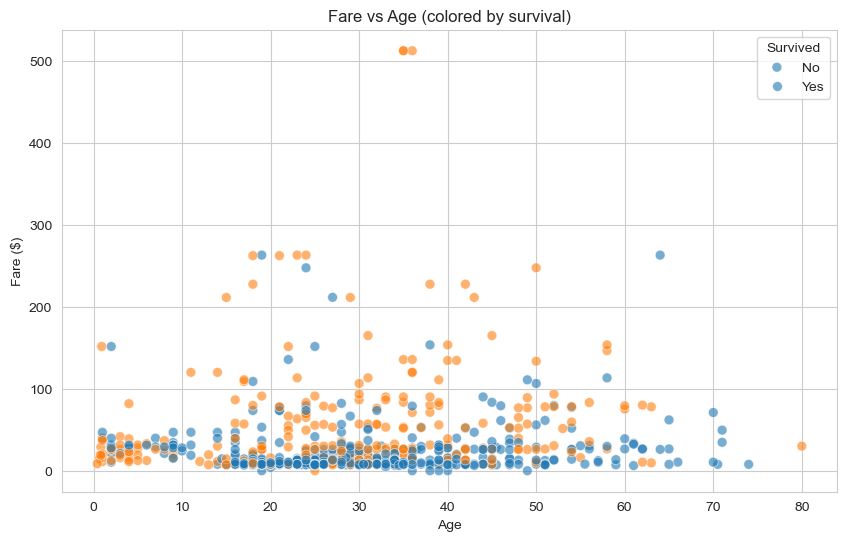

  Correlation analysis complete


In [6]:
# Correlation heatmap
corr_titanic = df[numeric_cols_titanic].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_titanic, annot=True, cmap="coolwarm", center=0)
plt.title("Titanic: Correlation Matrix")
plt.show()

# Scatter: Fare vs Age with survival coloring
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df["age"], y=df["fare"], hue=df["survived"], alpha=0.6, s=50)
plt.xlabel("Age")
plt.ylabel("Fare ($)")
plt.title("Fare vs Age (colored by survival)")
plt.legend(title="Survived", labels=["No", "Yes"])
plt.show()

print("  Correlation analysis complete")

---

# ITERATION 2: STOCK PRICES DATASET

Analyze Apple stock daily prices, volume, and volatility patterns.

## 2.1 Load and inspect stock data

In [7]:
# Load the dataset
df_stock = pd.read_csv("data/stocks_aapl.csv")

print("=" * 60)
print("STOCK PRICE DATASET (Apple AAPL)")
print("=" * 60)
print(f"Shape: {df_stock.shape}")
print(f"Columns: {list(df_stock.columns)}")
print(f"Date range: {df_stock['Date'].min()} to {df_stock['Date'].max()}")

print("\nFirst 5 rows:")
print(df_stock.head())

print("\nNumeric summary:")
print(df_stock[["Close", "High", "Low", "Volume"]].describe())

# Compute simple metrics
df_stock["Daily_Return"] = df_stock["Close"].pct_change() * 100
df_stock["Daily_Range"] = df_stock["High"] - df_stock["Low"]

print("\nDaily returns and range:")
print(df_stock[["Daily_Return", "Daily_Range"]].describe())

STOCK PRICE DATASET (Apple AAPL)
Shape: (731, 5)
Columns: ['Date', 'Close', 'Volume', 'High', 'Low']
Date range: 2023-01-01 to 2024-12-31

First 5 rows:
         Date       Close     Volume        High         Low
0  2023-01-01  150.993428   70080673  152.950174  149.516167
1  2023-01-02  150.716900  148475024  150.844612  150.380790
2  2023-01-03  152.012277  124052985  152.253457  149.776245
3  2023-01-04  155.058336   56238795  155.847180  154.795420
4  2023-01-05  154.590030  131266262  155.444601  151.770642

Numeric summary:
            Close        High         Low        Volume
count  731.000000  731.000000  731.000000  7.310000e+02
mean   144.855128  146.489456  143.206285  9.876076e+07
std     12.875069   12.875493   12.973268  2.826497e+07
min    122.946109  123.861195  121.342503  5.022470e+07
25%    133.919312  135.715876  132.190435  7.480777e+07
50%    142.531698  144.150407  141.008785  9.771802e+07
75%    155.227837  156.929836  153.230854  1.238996e+08
max    181.2712

## 2.2 Histograms: Price and volatility distributions

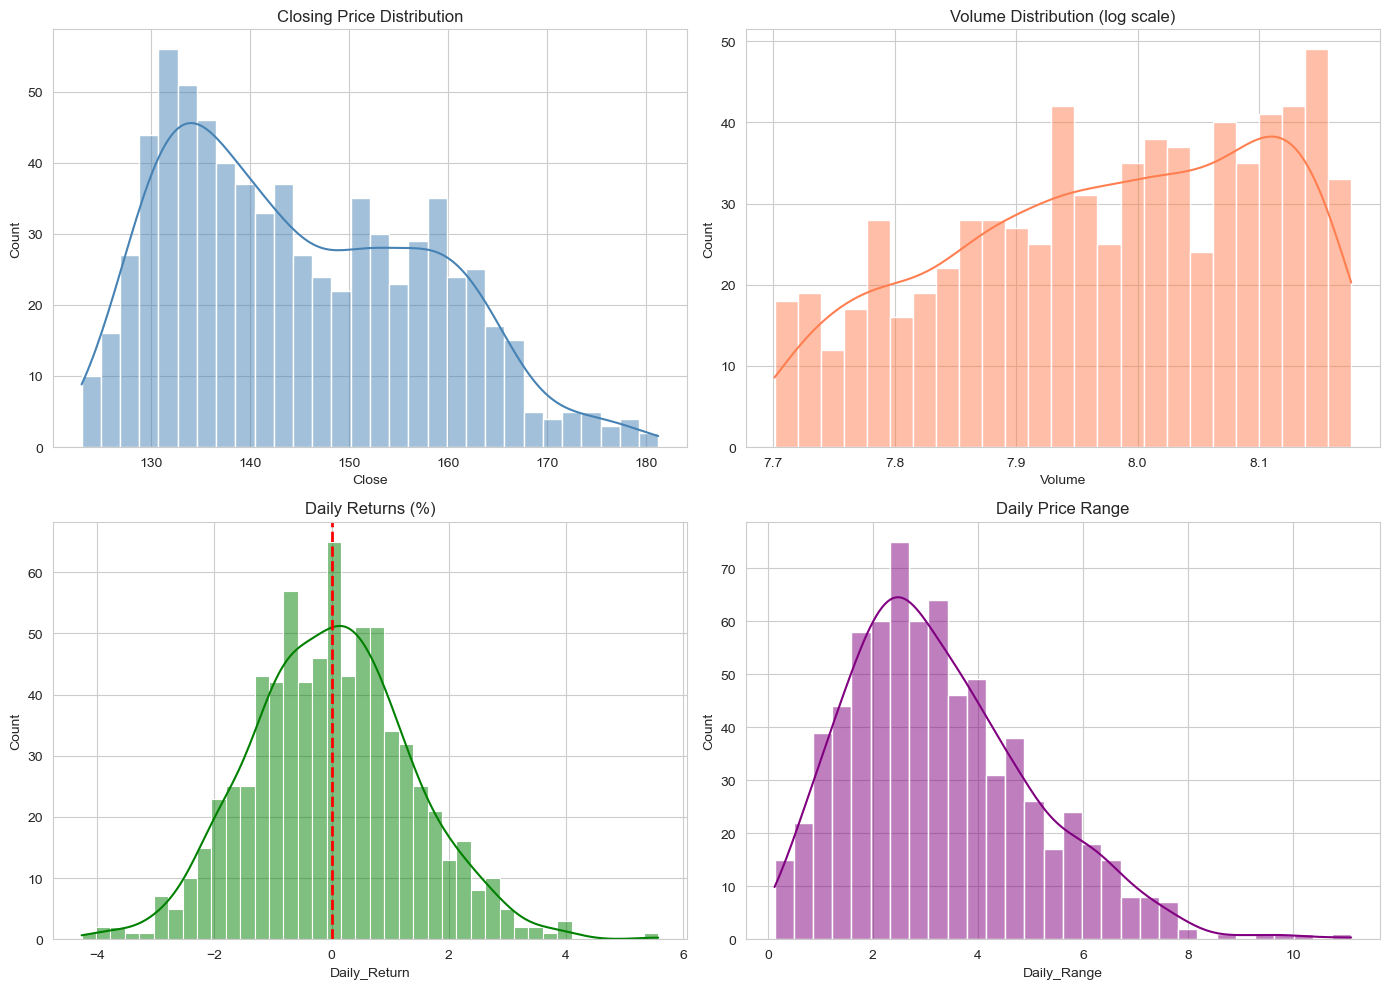

  Stock histograms complete


In [8]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Closing price distribution
sns.histplot(df_stock["Close"], bins=30, kde=True, ax=axes[0], color="steelblue")
axes[0].set_title("Closing Price Distribution")

# Plot 2: Volume distribution (log scale)
sns.histplot(np.log10(df_stock["Volume"]), bins=25, kde=True, ax=axes[1], color="coral")
axes[1].set_title("Volume Distribution (log scale)")

# Plot 3: Daily returns
sns.histplot(df_stock["Daily_Return"].dropna(), bins=40, kde=True, ax=axes[2], color="green")
axes[2].set_title("Daily Returns (%)")
axes[2].axvline(0, color="red", linestyle="--", linewidth=2)

# Plot 4: Daily price range
sns.histplot(df_stock["Daily_Range"], bins=30, kde=True, ax=axes[3], color="purple")
axes[3].set_title("Daily Price Range")

plt.tight_layout()
plt.show()

print("  Stock histograms complete")

## 2.3 Boxplots: Identify price and volume outliers

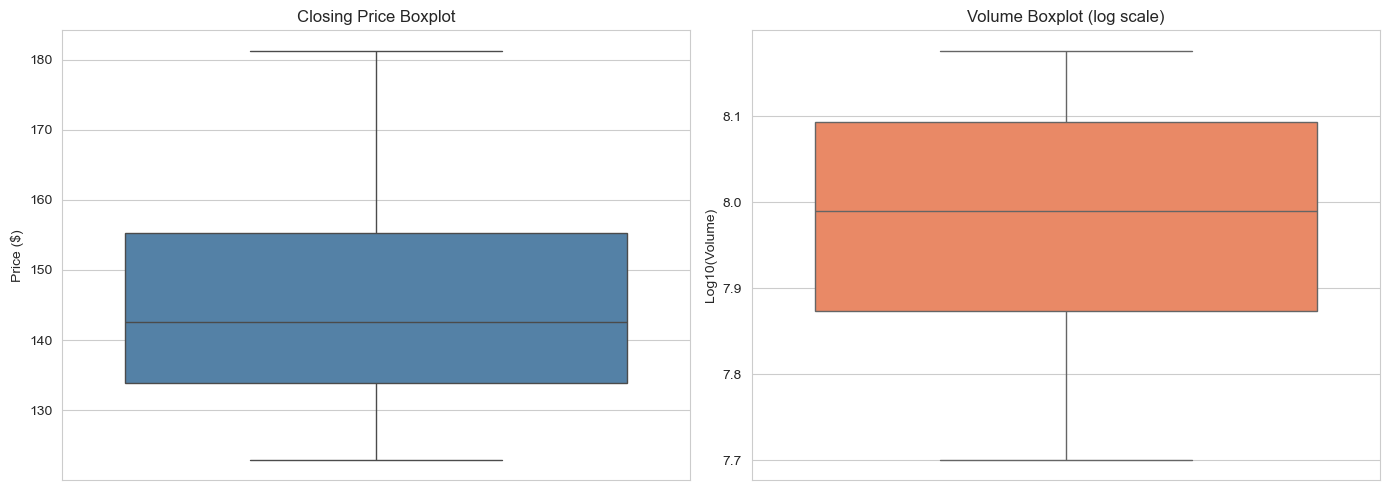

  Stock boxplots complete


In [9]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Boxplot 1: Close price
sns.boxplot(y=df_stock["Close"], ax=axes[0], color="steelblue")
axes[0].set_title("Closing Price Boxplot")
axes[0].set_ylabel("Price ($)")

# Boxplot 2: Volume
sns.boxplot(y=np.log10(df_stock["Volume"]), ax=axes[1], color="coral")
axes[1].set_title("Volume Boxplot (log scale)")
axes[1].set_ylabel("Log10(Volume)")

plt.tight_layout()
plt.show()

print("  Stock boxplots complete")

## 2.4 Correlations: Price components

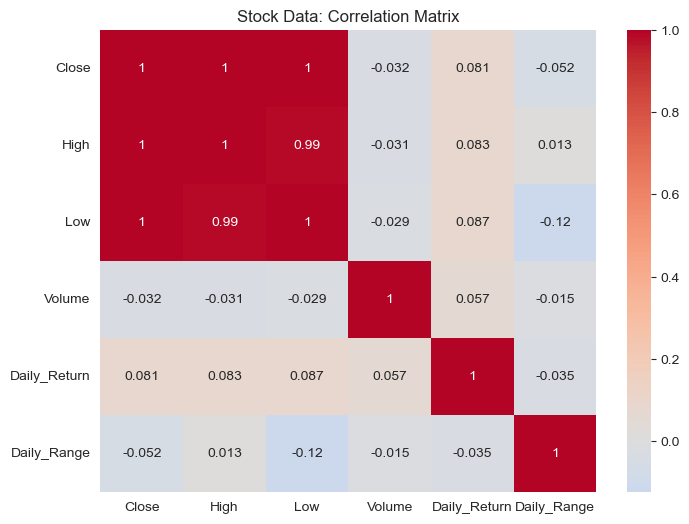

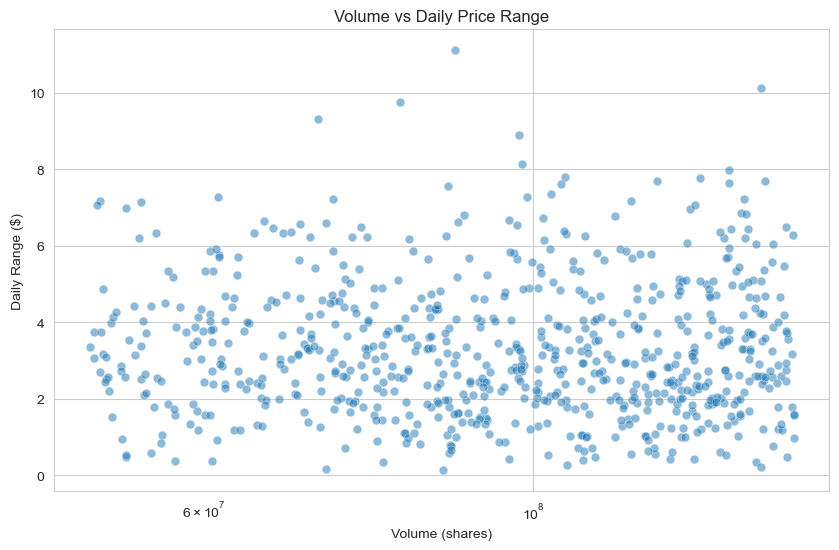

  Stock correlation analysis complete


In [10]:
# Correlation heatmap
stock_numeric = df_stock[["Close", "High", "Low", "Volume", "Daily_Return", "Daily_Range"]]
corr_stock = stock_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_stock, annot=True, cmap="coolwarm", center=0)
plt.title("Stock Data: Correlation Matrix")
plt.show()

# Scatter: Volume vs Daily Range
plt.figure(figsize=(10, 6))
sns.scatterplot(x=df_stock["Volume"], y=df_stock["Daily_Range"], alpha=0.5, s=40)
plt.xlabel("Volume (shares)")
plt.ylabel("Daily Range ($)")
plt.title("Volume vs Daily Price Range")
plt.xscale("log")
plt.show()

print("  Stock correlation analysis complete")

---

# ITERATION 3: WEATHER DATASET

Analyze NYC temperature, humidity, precipitation, and wind patterns.

## 3.1 Load and inspect weather data

In [11]:
# Load the dataset
df_weather = pd.read_csv("data/weather_nyc.csv")

print("=" * 60)
print("WEATHER DATASET (NYC)")
print("=" * 60)
print(f"Shape: {df_weather.shape}")
print(f"Columns: {list(df_weather.columns)}")
print(f"Date range: {df_weather['time'].min()} to {df_weather['time'].max()}")

print("\nFirst 5 rows:")
print(df_weather.head())

print("\nNumeric summary:")
print(df_weather[["temperature", "humidity", "precipitation", "wind_speed"]].describe())

print("\nMissing values:")
print(df_weather.isna().sum())

WEATHER DATASET (NYC)
Shape: (731, 5)
Columns: ['time', 'temperature', 'humidity', 'precipitation', 'wind_speed']
Date range: 2023-01-01T00:00 to 2024-12-31T00:00

First 5 rows:
               time  temperature  humidity  precipitation  wind_speed
0  2023-01-01T00:00          8.9       100            0.4        11.3
1  2023-01-02T00:00          4.9        82            0.0         9.5
2  2023-01-03T00:00          7.7        91            0.0         8.0
3  2023-01-04T00:00         10.1       100            0.0        10.5
4  2023-01-05T00:00          9.6        99            0.9         7.0

Numeric summary:
       temperature    humidity  precipitation  wind_speed
count   731.000000  731.000000     731.000000  731.000000
mean     13.246101   69.348837       0.121888   11.890698
std       8.872928   16.850920       0.630318    5.610423
min     -10.500000   29.000000       0.000000    0.000000
25%       5.950000   57.000000       0.000000    8.000000
50%      13.200000   69.000000      

## 3.2 Histograms: Weather variable distributions

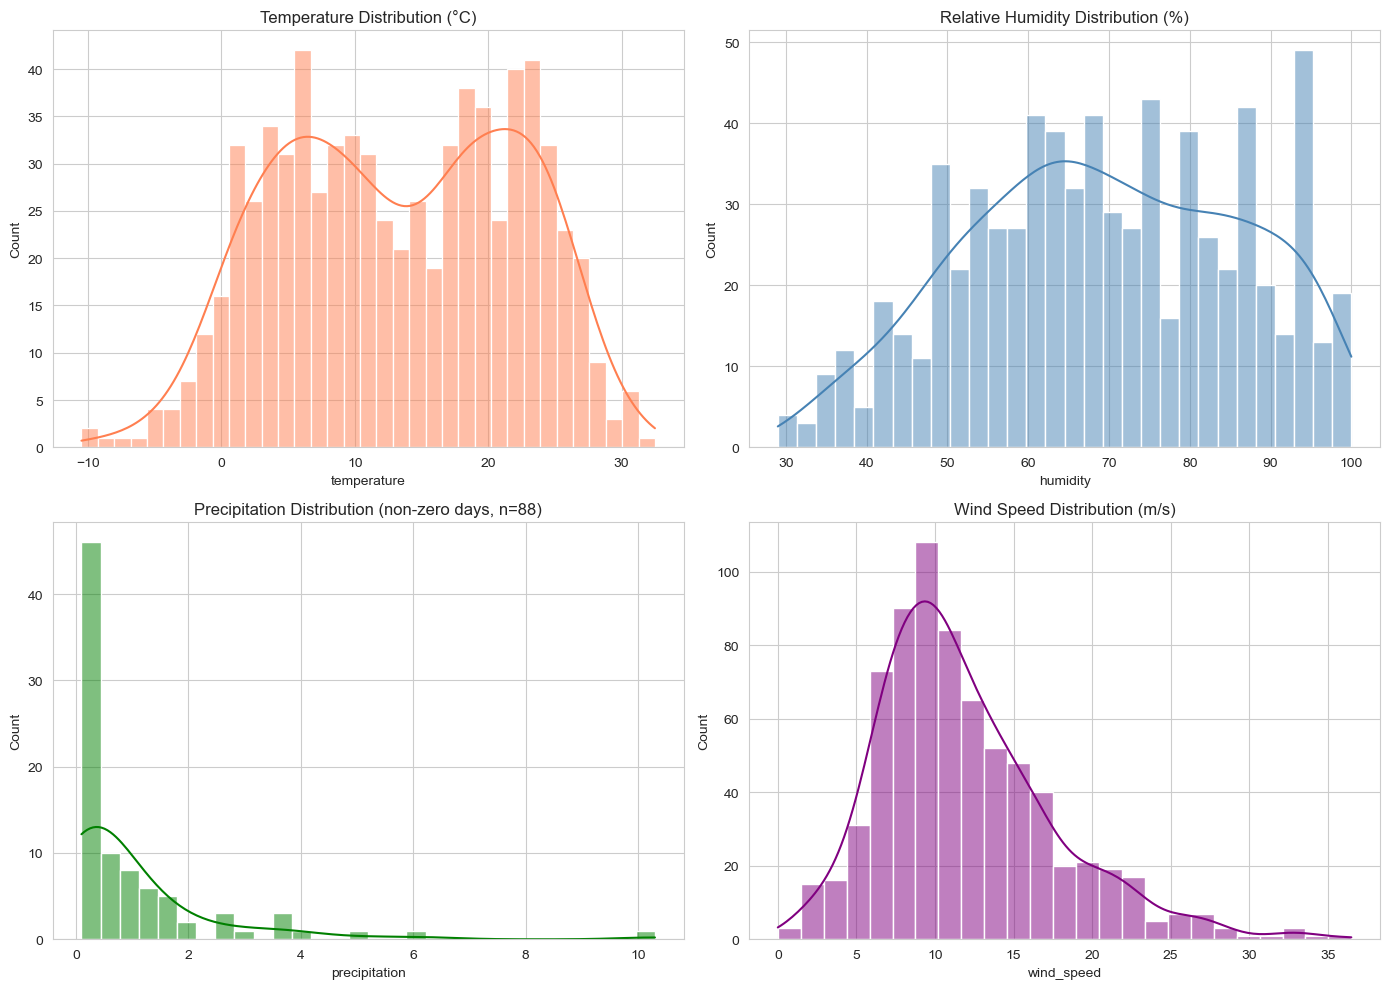

  Weather histograms complete


In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(14, 10))
axes = axes.flatten()

# Plot 1: Temperature
sns.histplot(df_weather["temperature"], bins=35, kde=True, ax=axes[0], color="coral")
axes[0].set_title("Temperature Distribution (°C)")

# Plot 2: Humidity
sns.histplot(df_weather["humidity"], bins=30, kde=True, ax=axes[1], color="steelblue")
axes[1].set_title("Relative Humidity Distribution (%)")

# Plot 3: Precipitation
# Exclude zeros for better visualization
precip_nonzero = df_weather[df_weather["precipitation"] > 0]["precipitation"]
sns.histplot(precip_nonzero, bins=30, kde=True, ax=axes[2], color="green")
axes[2].set_title(f"Precipitation Distribution (non-zero days, n={len(precip_nonzero)})")

# Plot 4: Wind speed
sns.histplot(df_weather["wind_speed"], bins=25, kde=True, ax=axes[3], color="purple")
axes[3].set_title("Wind Speed Distribution (m/s)")

plt.tight_layout()
plt.show()

print("  Weather histograms complete")

## 3.3 Boxplots: Seasonal and extreme weather

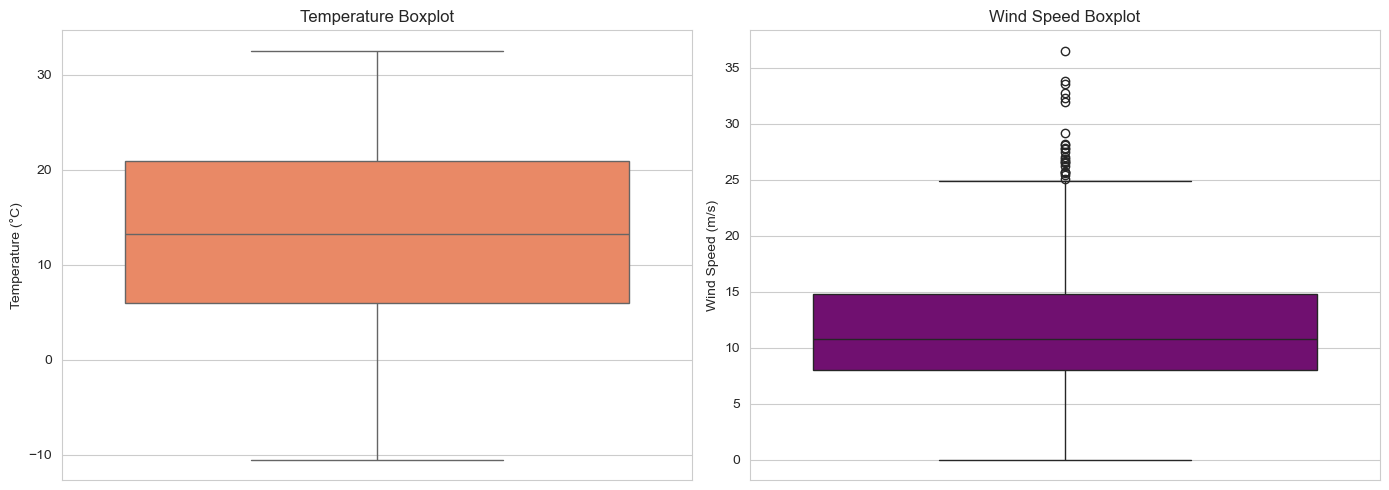

  Weather boxplots complete


In [13]:
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Boxplot 1: Temperature
sns.boxplot(y=df_weather["temperature"], ax=axes[0], color="coral")
axes[0].set_title("Temperature Boxplot")
axes[0].set_ylabel("Temperature (°C)")

# Boxplot 2: Wind speed
sns.boxplot(y=df_weather["wind_speed"], ax=axes[1], color="purple")
axes[1].set_title("Wind Speed Boxplot")
axes[1].set_ylabel("Wind Speed (m/s)")

plt.tight_layout()
plt.show()

print("  Weather boxplots complete")

## 3.4 Correlations: Environmental relationships

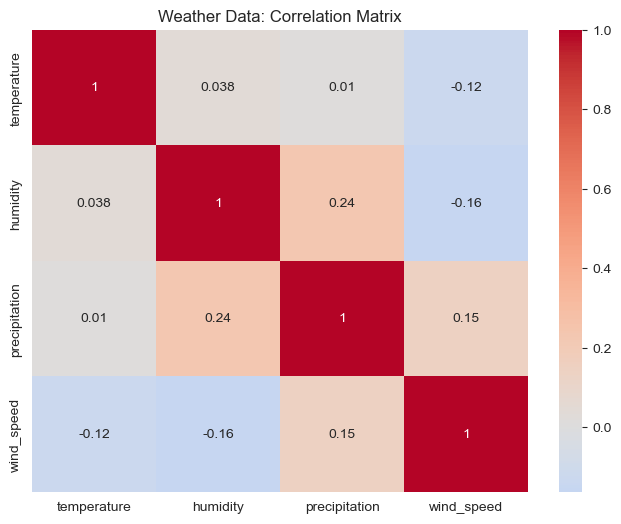

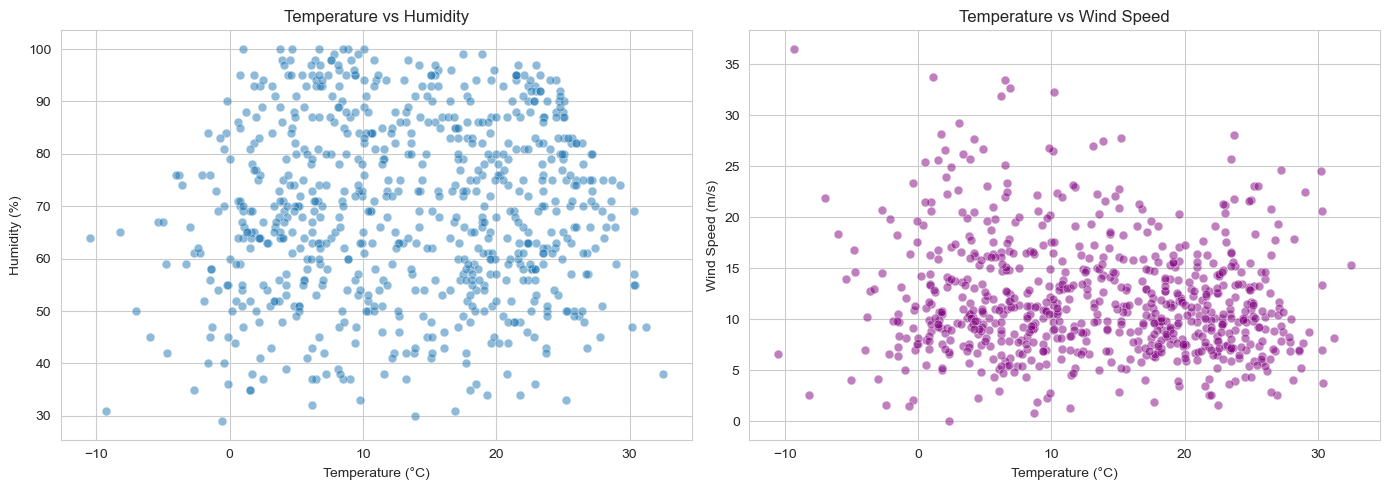

  Weather correlation analysis complete


In [14]:
# Correlation heatmap
weather_numeric = df_weather[["temperature", "humidity", "precipitation", "wind_speed"]]
corr_weather = weather_numeric.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr_weather, annot=True, cmap="coolwarm", center=0)
plt.title("Weather Data: Correlation Matrix")
plt.show()

# Scatter plots
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(14, 5))

# Temperature vs Humidity
sns.scatterplot(x=df_weather["temperature"], y=df_weather["humidity"], 
                alpha=0.5, s=40, ax=axes[0])
axes[0].set_xlabel("Temperature (°C)")
axes[0].set_ylabel("Humidity (%)")
axes[0].set_title("Temperature vs Humidity")

# Temperature vs Wind Speed
sns.scatterplot(x=df_weather["temperature"], y=df_weather["wind_speed"], 
                alpha=0.5, s=40, ax=axes[1], color="purple")
axes[1].set_xlabel("Temperature (°C)")
axes[1].set_ylabel("Wind Speed (m/s)")
axes[1].set_title("Temperature vs Wind Speed")

plt.tight_layout()
plt.show()

print("  Weather correlation analysis complete")

---

# WRAP-UP

## Key Takeaways

1. **Data Inspection is critical**: Always check shape, types, and missing values first.
2. **Multiple histograms reveal patterns**: Different datasets show different distributions (bimodal, skewed, uniform).
3. **Boxplots quickly identify outliers**: Use them for domain understanding and data quality checks.
4. **Correlations guide further analysis**: Strong correlations suggest relationships worth investigating.

## Next Steps

- Clean data (handle missing values, outliers)
- Group and aggregate (e.g., by survival, month, city)
- Build predictive models
- Create time series analysis (stocks, weather)
- Perform statistical tests on relationships

---

**Workshop Complete!**
Try running each iteration independently with your own questions in mind.

# Basic EDA: Loading data (read_csv), describe(), basic histograms and boxplots in Matplotlib/Seaborn

This notebook is designed as a 2.5-hour workshop for introductory exploratory data analysis.
It focuses on loading a CSV dataset, inspecting the data, computing summary statistics, and creating basic visualizations with Matplotlib and Seaborn.

## Workshop Plan (120 minutes)

Three 40-minute iterations, each with a different dataset:

| Iteration | Dataset | Time | Focus |
|-----------|---------|------|-------|
| 1 | Titanic (891 rows, mixed) | 40 min | Survival patterns, outliers |
| 2 | Stock prices (731 days) | 40 min | Time series, volatility |
| 3 | Weather (731 days) | 40 min | Correlations, distributions |

**Each 40-minute iteration:**
- 5 min — Load CSV, inspect shape/columns/summary
- 15 min — Histograms with parameter exploration (bins, KDE, colors)
- 10 min — Boxplots across features, identify outliers
- 8 min — Correlation and scatter plots
- 2 min — Discussion and observations


## Learning Objectives

By the end of this workshop, participants should be able to:

- Load a dataset from CSV using `pandas.read_csv()`
- Inspect dataset shape, columns, and data types
- Use `describe()` and other summary functions for numeric and categorical data
- Create histograms and boxplots with Matplotlib and Seaborn
- Identify outliers and distribution shapes
- Compute and visualize correlations between numeric features

In [15]:
# Install dependencies as needed:
# pip install pandas seaborn matplotlib
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

# Load the dataset
csv_path = "data/Exercise1.csv"
df = pd.read_csv(csv_path)

df.head()

,ID,BD1,BD2,BD3,BD4,BD5,BD6,BD7,BD8,BD9,DrugPlant
0,1001,789,68,16,90782,0,0,29,66,1402,0
1,1002,623,78,20,113023,0,0,31,6,1537,0
2,1003,583,24,18,28344,1,0,4,69,44,0


## 1. Loading and inspecting the data

First, check the shape, column names, and initial rows.
Use `head()`, `tail()`, and `sample()` to inspect representative records.

In [16]:
print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))

print("\nFirst 5 rows:")
print(df.head())

print("\nRandom sample:")
print(df.sample(min(5, len(df)), random_state=42))

Dataset shape: (3, 11)
Columns: ['ID', 'BD1', 'BD2', 'BD3', 'BD4', 'BD5', 'BD6', 'BD7', 'BD8', 'BD9', 'DrugPlant']

First 5 rows:
     ID  BD1  BD2  BD3     BD4  BD5  BD6  BD7  BD8   BD9  DrugPlant
0  1001  789   68   16   90782    0    0   29   66  1402          0
1  1002  623   78   20  113023    0    0   31    6  1537          0
2  1003  583   24   18   28344    1    0    4   69    44          0

Random sample:
     ID  BD1  BD2  BD3     BD4  BD5  BD6  BD7  BD8   BD9  DrugPlant
0  1001  789   68   16   90782    0    0   29   66  1402          0
1  1002  623   78   20  113023    0    0   31    6  1537          0
2  1003  583   24   18   28344    1    0    4   69    44          0


## 2. Understanding structure and summary statistics

Use `info()`, `describe()`, and value-count summaries to understand the data’s structure.

- `df.info()` for types and non-null counts
- `df.describe()` for numeric summary statistics
- `df.isna().sum()` for missing values

In [17]:
print("Data info:\n")
df.info()

print("\nNumeric summary statistics:\n")
print(df.describe())

print("\nMissing values by column:\n")
print(df.isna().sum())

Data info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3 entries, 0 to 2
Data columns (total 11 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ID         3 non-null      int64
 1   BD1        3 non-null      int64
 2   BD2        3 non-null      int64
 3   BD3        3 non-null      int64
 4   BD4        3 non-null      int64
 5   BD5        3 non-null      int64
 6   BD6        3 non-null      int64
 7   BD7        3 non-null      int64
 8   BD8        3 non-null      int64
 9   BD9        3 non-null      int64
 10  DrugPlant  3 non-null      int64
dtypes: int64(11)
memory usage: 396.0 bytes

Numeric summary statistics:

           ID         BD1        BD2   BD3            BD4       BD5  BD6  \
count     3.0    3.000000   3.000000   3.0       3.000000  3.000000  3.0   
mean   1002.0  665.000000  56.666667  18.0   77383.000000  0.333333  0.0   
std       1.0  109.233694  28.728615   2.0   43900.833261  0.577350  0.0   
min    1001.0  

## 3. Histograms for distribution analysis

Plot numeric feature distributions with histograms.
This helps reveal skew, modality, and value ranges.

Numeric columns: ['BD1', 'BD2', 'BD3', 'BD4', 'BD5', 'BD6', 'BD7', 'BD8', 'BD9', 'DrugPlant']


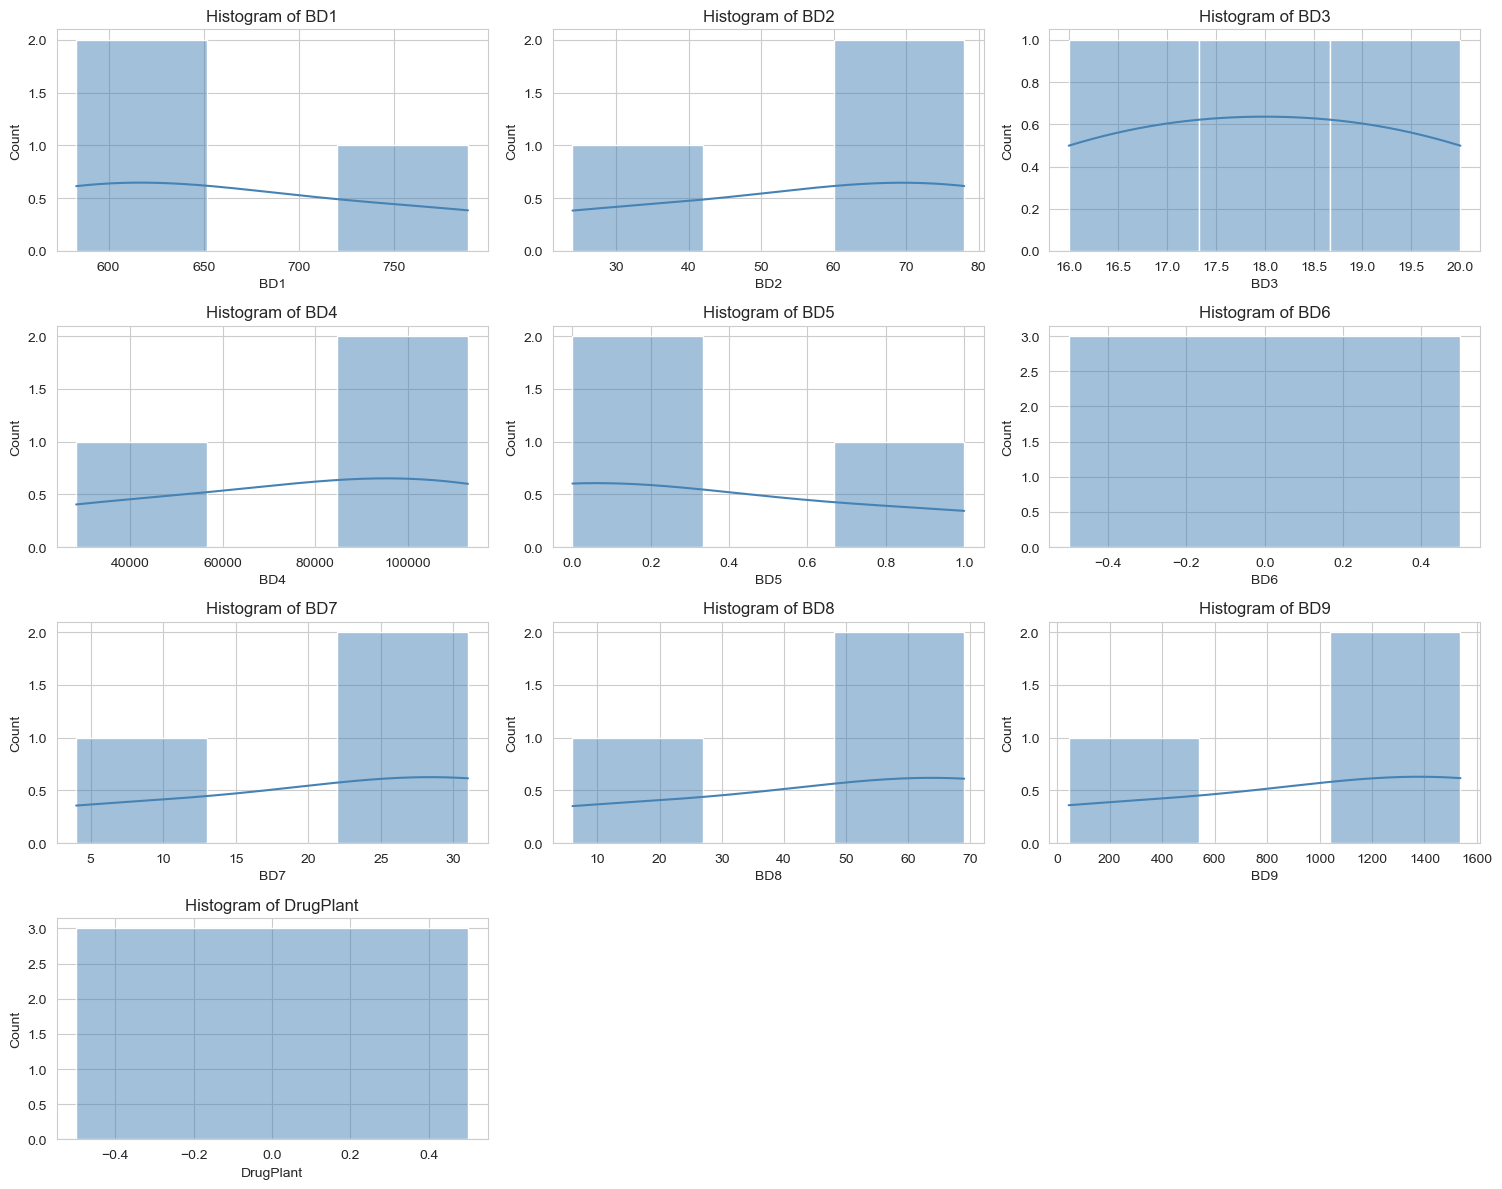

In [18]:
# Select numeric columns (excluding ID if present)
numeric_cols = df.select_dtypes(include="number").columns.tolist()
if "ID" in numeric_cols:
    numeric_cols.remove("ID")

print("Numeric columns:", numeric_cols)

fig, axes = plt.subplots(nrows=len(numeric_cols) // 3 + 1, ncols=3, figsize=(15, 12))
axes = axes.flatten()
for idx, col in enumerate(numeric_cols):
    sns.histplot(df[col], kde=True, ax=axes[idx], color="steelblue")
    axes[idx].set_title(f"Histogram of {col}")

for idx in range(len(numeric_cols), len(axes)):
    fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

## 4. Boxplots for outlier detection and spread

Use boxplots to identify outliers and compare distributions across numeric features.
Boxplots are especially useful for detecting wide variation and extreme values.

/var/folders/n8/08b2nd114jdfnsydb_4mj4fw0000gn/T/ipykernel_94651/4219571168.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="feature", y="value", data=melted, palette="Set2")


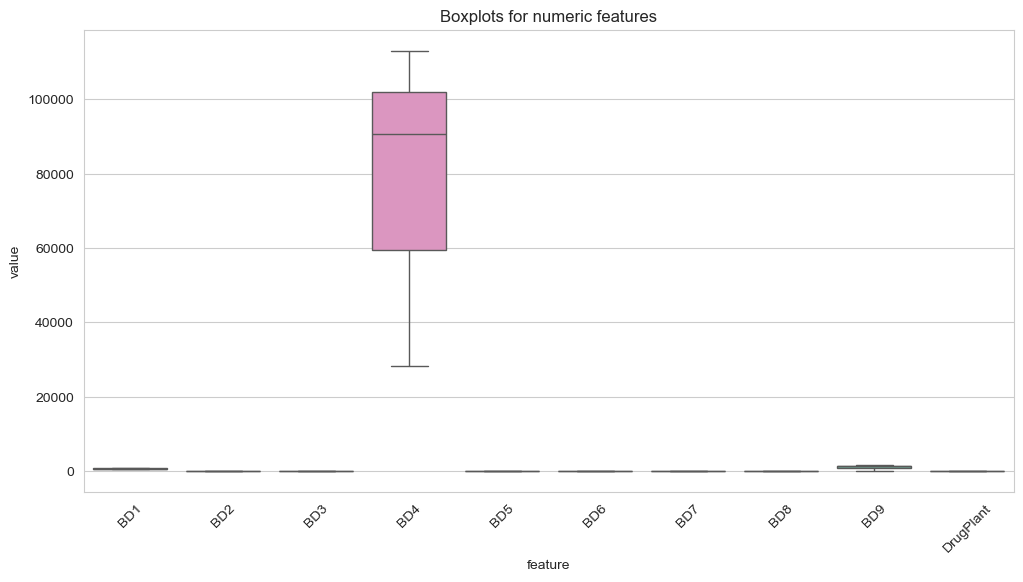

In [19]:
# Create a long-form DataFrame for boxplots
melted = df.melt(id_vars=[col for col in df.columns if col not in numeric_cols],
                 value_vars=numeric_cols,
                 var_name="feature",
                 value_name="value")

plt.figure(figsize=(12, 6))
sns.boxplot(x="feature", y="value", data=melted, palette="Set2")
plt.title("Boxplots for numeric features")
plt.xticks(rotation=45)
plt.show()

## 5. Correlation and scatter plots

Use correlation matrices to identify pairs of strongly related numeric features.
A scatter plot can show the relationship between two variables visually.

                BD1       BD2       BD3       BD4       BD5  BD6       BD7  \
BD1        1.000000  0.507945 -0.759839  0.436434 -0.650112  NaN  0.598167   
BD2        0.507945  1.000000  0.174042  0.996708 -0.984738  NaN  0.994129   
BD3       -0.759839  0.174042  1.000000  0.253310  0.000000  NaN  0.066470   
BD4        0.436434  0.996708  0.253310  1.000000 -0.967385  NaN  0.982083   
BD5       -0.650112 -0.984738  0.000000 -0.967385  1.000000  NaN -0.997788   
BD6             NaN       NaN       NaN       NaN       NaN  NaN       NaN   
BD7        0.598167  0.994129  0.066470  0.982083 -0.997788  NaN  1.000000   
BD8        0.292888 -0.674843 -0.844150 -0.732453  0.536107  NaN -0.591032   
BD9        0.585826  0.995669  0.081741  0.984854 -0.996654  NaN  0.999883   
DrugPlant       NaN       NaN       NaN       NaN       NaN  NaN       NaN   

                BD8       BD9  DrugPlant  
BD1        0.292888  0.585826        NaN  
BD2       -0.674843  0.995669        NaN  
BD3       -0

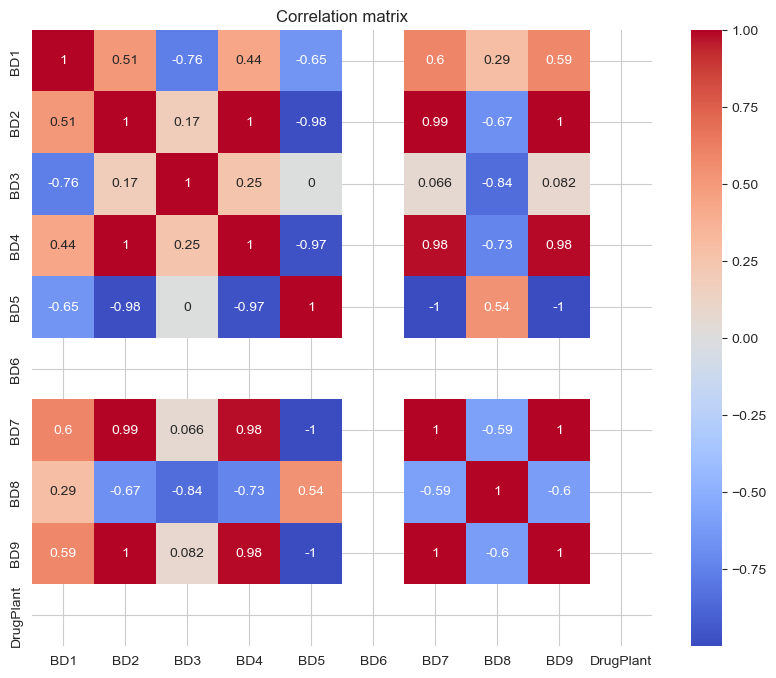

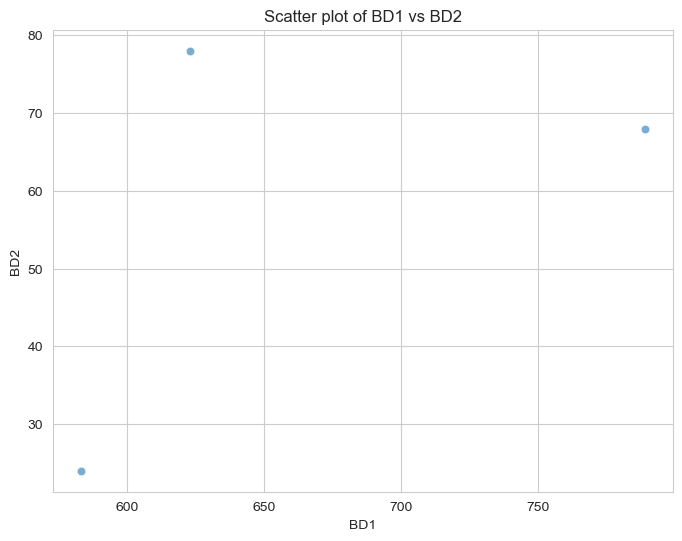

In [20]:
# Correlation matrix
corr = df[numeric_cols].corr()
print(corr)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap="coolwarm", center=0)
plt.title("Correlation matrix")
plt.show()

# Example scatter plot for two numeric features
if len(numeric_cols) >= 2:
    x_col, y_col = numeric_cols[0], numeric_cols[1]
    plt.figure(figsize=(8, 6))
    sns.scatterplot(x=df[x_col], y=df[y_col], alpha=0.6)
    plt.title(f"Scatter plot of {x_col} vs {y_col}")
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.show()

## 6. Wrap-up and next steps

Suggested next steps:
- Clean missing values and duplicate rows
- Explore categorical values and group summaries
- Build pair plots or more advanced visualizations
- Start feature engineering for modeling

For the workshop, allow time for participants to ask questions, review their plots, and practice with a second dataset.